In [23]:
# Loading the Library
import numpy as np # linear algebra
import pandas as pd # data processing

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns
import matplotlib.style as style
from matplotlib import pyplot
from matplotlib.ticker import ScalarFormatter

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.model_selection import GridSearchCV

import lightgbm as lgb
from lightgbm import LGBMClassifier

import random

In [25]:
pd.set_option("display.max_rows",None)
pd.set_option("display.max_columns",None)

In [27]:
# Loading the Data
train_data = pd.read_csv('train.csv')
test_data = pd.read_csv('test.csv')

In [29]:
# Now before moving forward let’s have a quick look at the training and test sets
train_data.head()

,id,bone_length,rotting_flesh,hair_length,has_soul,color,type
0,0,0.354512,0.350839,0.465761,0.781142,clear,Ghoul
1,1,0.575560,0.425868,0.531401,0.439899,green,Goblin
2,2,0.467875,0.354330,0.811616,0.791225,black,Ghoul
3,4,0.776652,0.508723,0.636766,0.884464,black,Ghoul
4,5,0.566117,0.875862,0.418594,0.636438,green,Ghost


In [31]:
test_data.head()

,id,bone_length,rotting_flesh,hair_length,has_soul,color
0,3,0.471774,0.387937,0.706087,0.698537,black
1,6,0.427332,0.645024,0.565558,0.451462,white
2,9,0.549602,0.491931,0.660387,0.449809,black
3,10,0.638095,0.682867,0.471409,0.356924,white
4,13,0.361762,0.583997,0.377256,0.276364,black


#### Data Preparation

In [42]:
train_data = pd.get_dummies(train_data, columns = ['color'], prefix = ['color'])

In [44]:
map_type = {"Ghoul":1, "Goblin":2, "Ghost":0} # change ghoul, goblin, ghost to 1, 2 and 0


In [46]:
train_data.loc[:, "type"] = train_data.type.map(map_type)

In [48]:
train_data = train_data.set_index('id')

In [65]:
if y_train.dtype == 'object':
    le_y = LabelEncoder()
    y_train = le_y.fit_transform(y_train.astype(str))
    y_test = le_y.transform(y_test.astype(str))


In [67]:
X = train_data.drop(["type"],axis=1)
y = train_data.type

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.4, random_state=42)

In [81]:
print(y_train.dtype)
print(y_train.head())

object
id
506    2
205    2
159    1
831    1
216    0
Name: type, dtype: object


In [85]:
from sklearn.preprocessing import LabelEncoder

# Encode features
for col in X_train.columns:
    if X_train[col].dtype == 'object':
        le = LabelEncoder()
        X_train[col] = le.fit_transform(X_train[col].astype(str))
        X_test[col] = le.transform(X_test[col].astype(str))


#### LightGBM Classifier


In [88]:
param_grid = {
    'class_weight': [None, 'balanced'],
    'boosting_type': ['gbdt', 'goss', 'dart'],
    'num_leaves': list(range(30, 150)),
    'learning_rate': [0.01,0.1,0.5],
    'subsample_for_bin': [20000,50000,100000,120000,150000],
    'min_child_samples': [20,50,100,200,500],
    'colsample_bytree': [0.6,0.8,1],
    "max_depth": [5,10,50,100]
}

lgbm = LGBMClassifier() # Shortname the LGBMClassifier()

In [92]:
from sklearn.preprocessing import LabelEncoder
from lightgbm import LGBMClassifier

le_y = LabelEncoder()
y_train = le_y.fit_transform(y_train.astype(str))
y_test = le_y.transform(y_test.astype(str))

lgbm_tuned = LGBMClassifier(boosting_type='gbdt',
                            class_weight=None,
                            min_child_samples=20,
                            num_leaves=30,
                            subsample_for_bin=20000,
                            learning_rate=0.01, 
                            max_depth=10, 
                            n_estimators=40, 
                            colsample_bytree=0.6)

lgbm_tuned.fit(X_train, y_train)
y_test_pred = lgbm_tuned.predict(X_test)

from sklearn.metrics import accuracy_score
score = round(accuracy_score(y_test, y_test_pred), 3)
print(score)


[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000034 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 308
[LightGBM] [Info] Number of data points in the train set: 222, number of used features: 8
[LightGBM] [Info] Start training from score -1.168571
[LightGBM] [Info] Start training from score -1.045969
[LightGBM] [Info] Start training from score -1.085189
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits 

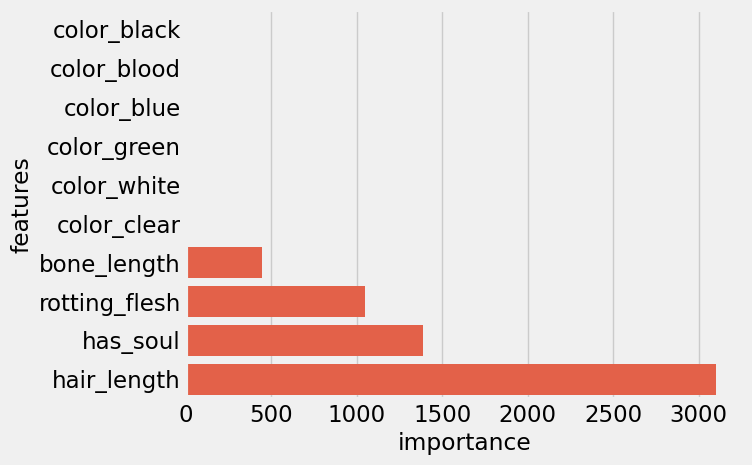

In [96]:
sns.set_context("talk")
style.use('fivethirtyeight')

fi = pd.DataFrame()
fi['features'] = X.columns.values.tolist()
fi['importance'] = lgbm_tuned.booster_.feature_importance(importance_type='gain')

sns.barplot(x='importance', y='features', data=fi.sort_values(by='importance', ascending=True))
plt.show()